<a href="https://colab.research.google.com/github/Riyaz127/TNS-Practice/blob/main/Linear_and_Logistic_(Practice).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

# Load the California housing dataset
housing = fetch_california_housing(as_frame=True)

# Create a DataFrame from the dataset
df = housing.frame
df['MedHouseVal'] = housing.target
print(df)


       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  MedHouseVal  
0      

In [2]:
# Explonatory Data Analysis(EDA)
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [3]:
#Counting Error Values.
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


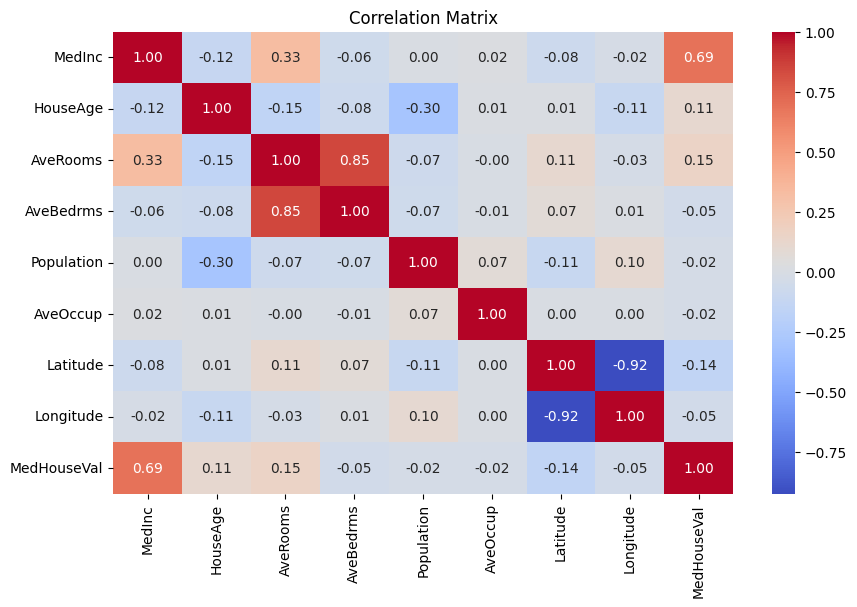

In [4]:
#Plotting the Correlation Matrix.
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [5]:
# Train Test Split
from sklearn.model_selection import train_test_split

X = df.drop('MedHouseVal', axis=1)  # Features
y = df['MedHouseVal']              # Target variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [6]:
#Part-2 : Linear Regression.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
# Train the model
model=LinearRegression()
model.fit(X_train,y_train)
#Prediction
y_pred=model.predict(X_test)

print("Actual: ",y_test)
print("Predicted: ", y_pred)
print("MAE: ",mean_absolute_error(y_test,y_pred))
print("MSE: ",mean_squared_error(y_test,y_pred))
print("R2 Score: ",r2_score(y_test,y_pred))

Actual:  20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: MedHouseVal, Length: 4128, dtype: float64
Predicted:  [0.71912284 1.76401657 2.70965883 ... 4.46877017 1.18751119 2.00940251]
MAE:  0.5332001304956553
MSE:  0.5558915986952444
R2 Score:  0.5757877060324508


In [7]:
"""
Analysis Question: Based on the R2 score and MAE ,
is your model performing well?
are there signs of underfitting or overfitting?"""
"""Underfitting:
A moderate R2 score (0.576) and a somewhat high MAE
(0.533 relative to the target scale)
often suggest that the model might be underfitting the data.
This means the model is too simple to capture the underlying patterns in the data.
Overfitting:
There are no immediate signs of overfitting here.
Overfitting would typically manifest as a very high R2 score on the training data
but a significantly lower R2 score on the test data
(or high training accuracy and low test accuracy)."""

'Underfitting:\nA moderate R2 score (0.576) and a somewhat high MAE\n(0.533 relative to the target scale)\noften suggest that the model might be underfitting the data.\nThis means the model is too simple to capture the underlying patterns in the data.\nOverfitting:\nThere are no immediate signs of overfitting here.\nOverfitting would typically manifest as a very high R2 score on the training data\nbut a significantly lower R2 score on the test data\n(or high training accuracy and low test accuracy).'

In [8]:
#Part-3 : Logistic Regression.
#Goal to predict a house is Expensive or Not Expensive.


Accuracy: 0.9072

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.98      0.91      2077
           1       0.97      0.83      0.90      2051

    accuracy                           0.91      4128
   macro avg       0.92      0.91      0.91      4128
weighted avg       0.92      0.91      0.91      4128


Confusion Matrix
[[2033   44]
 [ 339 1712]]


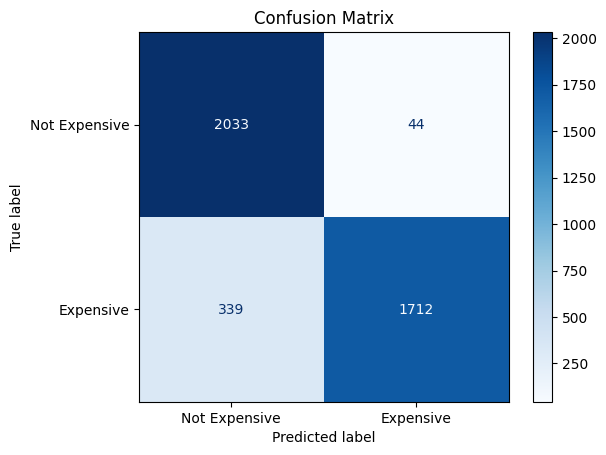

In [14]:
# ==========================
# Logistic Regression
# California Housing Dataset
# ==========================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Load Dataset

# Create Binary Target
median_value = df["MedHouseVal"].median()

df["Expensive"] = np.where(df["MedHouseVal"] > median_value, 1, 0)

# Features and Target
X = df.drop(["MedHouseVal", "Expensive"], axis=1)
y = df["Expensive"]

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)


# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Expensive", "Expensive"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()